## Data Visualisation with Python

In [1]:
# Import the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Step Process
1. Load Data
2. Inspect Data
3. Clean Data (if needed)
4. Explore + Visualise Data
5. Derive insights from Data Exploration/Visualisation

### Example 1: Forbes 2022 Data

#### 1. Load Data

In [2]:
forbes = pd.read_csv("forbes_2022.csv")
forbes

,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,$219 B,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,$171 B,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,$158 B,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,$129 B,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,$118 B,91,United States,Berkshire Hathaway,Finance & Investments
...,...,...,...,...,...,...,...,...
2595,2595,2578,Jorge Gallardo Ballart,$1 B,80,Spain,pharmaceuticals,Healthcare
2596,2596,2578,Nari Genomal,$1 B,82,Philippines,apparel,Fashion & Retail
2597,2597,2578,Ramesh Genomal,$1 B,71,Philippines,apparel,Fashion & Retail
2598,2598,2578,Sunder Genomal,$1 B,68,Philippines,garments,Fashion & Retail


#### 2. Inspect Data

In [3]:
#If True, means duplicate
forbes.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2595    False
2596    False
2597    False
2598    False
2599    False
Length: 2600, dtype: bool

In [5]:
forbes.duplicated().sum()

0

In [6]:
forbes.isnull().sum()

Unnamed: 0    0
rank          0
name          0
networth      0
age           0
country       0
source        0
industry      0
dtype: int64

In [6]:
#if has null value
#forbes.dropna()


In [7]:
#Check data type, see if the type makes sense
forbes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 8 columns):
Unnamed: 0    2600 non-null int64
rank          2600 non-null int64
name          2600 non-null object
networth      2600 non-null object
age           2600 non-null int64
country       2600 non-null object
source        2600 non-null object
industry      2600 non-null object
dtypes: int64(3), object(5)
memory usage: 162.6+ KB


#### 3. Clean Data

In [12]:
#Dtype is object indicates a generic type that can represent any Python object, including string, numbers..
#for a dataframe in pandas, it usually represents string

#Replace the $ and B with empty string
#str.replace(oldvalue,newvalue,count)
forbes["networth"] = forbes["networth"].str.replace("$","")
forbes["networth"] = forbes["networth"].str.replace("B","")

#Change type to numeric
forbes["networth"] = pd.to_numeric(forbes["networth"])
forbes.info()

AttributeError: Can only use .str accessor with string values, which use np.object_ dtype in pandas

#### 4. Explore Data

In [14]:
forbes.head()

,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,219.0,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,171.0,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,158.0,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,129.0,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,118.0,91,United States,Berkshire Hathaway,Finance & Investments


In [23]:
# Finding the industry with the highest number of billionaires
#value_counts() counts the frequency of unique values in specific columns of a dataframe
forbes["industry"].value_counts().sort_index()

Automotive                      69
Construction & Engineering      43
Diversified                    178
Energy                          93
Fashion & Retail               246
Finance & Investments          386
Food & Beverage                201
Gambling & Casinos              23
Healthcare                     212
Logistics                       35
Manufacturing                  322
Media & Entertainment           95
Metals & Mining                 67
Real Estate                    189
Service                         51
Sports                          26
Technology                     329
Telecom                         35
Name: industry, dtype: int64

In [22]:
# To display the top 5 industries with the most number of billionaires
forbes["country"].value_counts()[:5]

United States    719
China            515
India            161
Germany          130
Russia            81
Name: country, dtype: int64

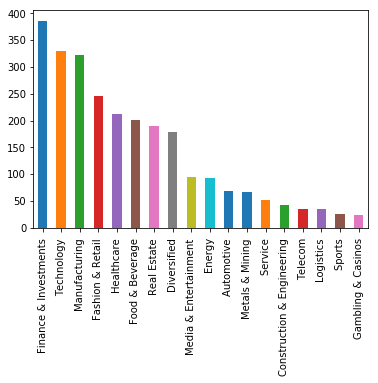

In [25]:
# show the number of billionaires in each industry with bar chart
forbes["industry"].value_counts().plot(kind="bar")

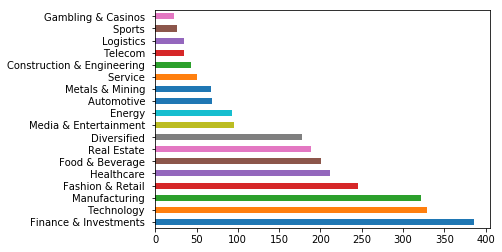

In [26]:
#Horizontal bar
forbes["industry"].value_counts().plot(kind="barh")

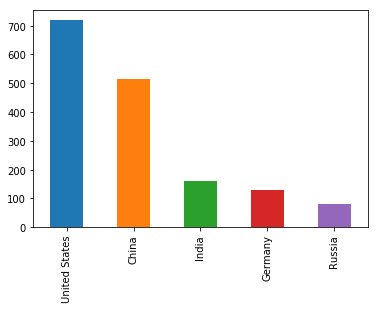

In [27]:
# Finding the country with the highest number of billionaires
forbes["country"].value_counts()[0:5].plot(kind="bar")

In [ ]:
#display the top 3 countries with the most billionaries


In [28]:
# Find the billionaires with networth more than 60 billion dollars
#To filter a dataframe base on a condition, we need to use dataframe[condition] where the condition is a boolean expression
#condition=forbes['networth']>=60,True-more than or equal 60, False-less than 60
forbes[forbes["networth"]>=60]
# OR


,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,219.0,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,171.0,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,158.0,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,129.0,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,118.0,91,United States,Berkshire Hathaway,Finance & Investments
5,5,6,Larry Page,111.0,49,United States,Google,Technology
6,6,7,Sergey Brin,107.0,48,United States,Google,Technology
7,7,8,Larry Ellison,106.0,77,United States,software,Technology
8,8,9,Steve Ballmer,91.4,66,United States,Microsoft,Technology
9,9,10,Mukesh Ambani,90.7,64,India,diversified,Diversified


In [31]:
#find the top 5 youngest billionaires
forbes.sort_values(by=["age"])[:5]

,Unnamed: 0,rank,name,networth,age,country,source,industry
1311,1311,1292,Kevin David Lehmann,2.4,19,Germany,drugstores,Fashion & Retail
2062,2062,1929,Wang Zelong,1.5,25,China,chemicals,Metals & Mining
1975,1975,1929,Pedro Franceschi,1.5,25,Brazil,fintech,Finance & Investments
2190,2190,2190,Alexandra Andresen,1.3,25,Norway,investments,Diversified
1961,1961,1929,Henrique Dubugras,1.5,26,Brazil,fintech,Finance & Investments


In [ ]:
# rearrange the dataframe by ascending or descending order of specific column
#parameter of sort_values: by-specify label to sort by, axis:0 or 1, ascending:True or False


In [36]:
# Finding the top 5 youngest people who have networth of more than 50 billion
forbes_more_50 = forbes[forbes["networth"]>=70]
forbes_more_50.sort_values(by=["age"])[0:10]

#Or

,Unnamed: 0,rank,name,networth,age,country,source,industry
6,6,7,Sergey Brin,107.0,48,United States,Google,Technology
5,5,6,Larry Page,111.0,49,United States,Google,Technology
0,0,1,Elon Musk,219.0,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,171.0,58,United States,Amazon,Technology
10,10,11,Gautam Adani & family,90.0,59,India,"infrastructure, commodities",Diversified
9,9,10,Mukesh Ambani,90.7,64,India,diversified,Diversified
3,3,4,Bill Gates,129.0,66,United States,Microsoft,Technology
8,8,9,Steve Ballmer,91.4,66,United States,Microsoft,Technology
13,13,14,Francoise Bettencourt Meyers & family,74.8,68,France,L'Oréal,Fashion & Retail
2,2,3,Bernard Arnault & family,158.0,73,France,LVMH,Fashion & Retail


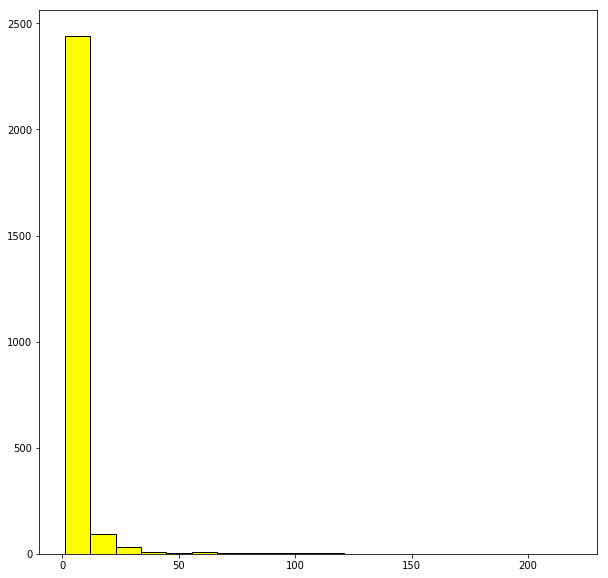

In [40]:
ig, ax = plt.subplots(figsize=(10,10))
ax.hist(forbes.networth, bins=20,edgecolor="black",color="yellow")
plt.show()

In [ ]:
#Using the method we used previously

# the higher the bin, the closer it is to the distribution plot which will be explained later
 #Notice the graphs are still similar to each other

##### Data Visualisation - Distribution Plot
- Shows how a variable in your data is distributed

# Distribution Plot

> parameter:
* data: dataframe name
* x,y,hue: variable name
* kind:{“hist”, “kde”, “ecdf”} hist by default, same as histplot(), kdeplot(), ecdfplot(univariate data only)
* color, palette, height...

1.   kernel density estimation:KDE represents the data using a continuous probability density curve, more smooth
2.    empirical cumulative distribution function: represents the proportion or counts of observations


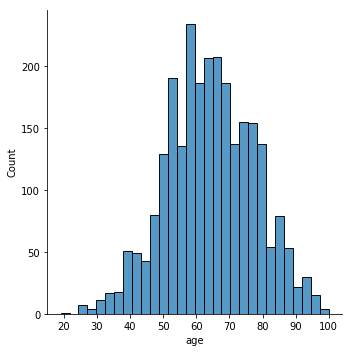

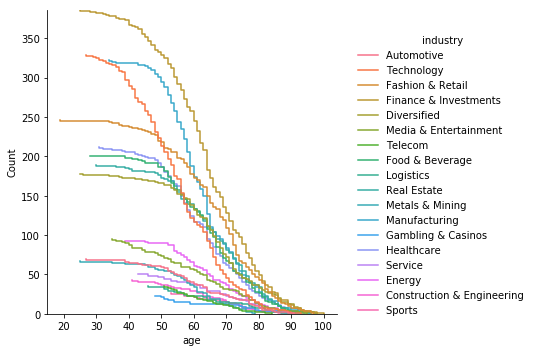

In [57]:
#Distribution plot of the age variable
sns.displot(x="age", data=(forbes))
plt.show()

sns.displot(x="age", hue="industry", kind="ecdf", data=forbes, stat="count", complementary=True)

Observation from dataset:
1. Most saturated industry/best industry (Finance & Investments)
2. Country with the most opportunity (US) - may be too saturated
3. Who to learn from (THose that really made it)
4. Probable age for someone to get really rich (50-70 years old)

### Example 2: Annual Sales 2018 Data

#### 1. Load Data

In [60]:
data = pd.read_csv("2018_annual.csv")
data.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,0,248151,AA Batteries (4-pack),4,3.84,2018-09-17 14:44:00,"883 West St, Boston, MA 02215"
1,1,248152,USB-C Charging Cable,2,11.95,2018-09-29 10:19:00,"71 Ridge St, New York City, NY 10001"
2,2,248153,USB-C Charging Cable,1,11.95,2018-09-16 17:48:00,"372 Spruce St, Portland, OR 97035"
3,3,248154,27in FHD Monitor,1,149.99,2018-09-27 07:52:00,"315 Meadow St, Atlanta, GA 30301"
4,4,248155,USB-C Charging Cable,1,11.95,2018-09-01 19:03:00,"408 Lake St, San Francisco, CA 94016"


In [63]:
#parameter of drop: label, axis: 1 for column, 0 for index, default 0
#Better to name it with another variable so that you can keep the original dataset under the variable 'data'
df = data.drop("Unnamed: 0", axis=1)
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,248151,AA Batteries (4-pack),4,3.84,2018-09-17 14:44:00,"883 West St, Boston, MA 02215"
1,248152,USB-C Charging Cable,2,11.95,2018-09-29 10:19:00,"71 Ridge St, New York City, NY 10001"
2,248153,USB-C Charging Cable,1,11.95,2018-09-16 17:48:00,"372 Spruce St, Portland, OR 97035"
3,248154,27in FHD Monitor,1,149.99,2018-09-27 07:52:00,"315 Meadow St, Atlanta, GA 30301"
4,248155,USB-C Charging Cable,1,11.95,2018-09-01 19:03:00,"408 Lake St, San Francisco, CA 94016"


#### 2. Inspect Data

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 7 columns):
Unnamed: 0          185950 non-null int64
Order ID            185950 non-null int64
Product             185950 non-null object
Quantity Ordered    185950 non-null int64
Price Each          185950 non-null float64
Order Date          185950 non-null object
Purchase Address    185950 non-null object
dtypes: float64(1), int64(3), object(3)
memory usage: 9.9+ MB


#### 3. Clean Data

In [65]:
#Convert 'Order Date' column into datetime type
df["Order Date"]=df["Order Date"].apply(pd.to_datetime)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 6 columns):
Order ID            185950 non-null int64
Product             185950 non-null object
Quantity Ordered    185950 non-null int64
Price Each          185950 non-null float64
Order Date          185950 non-null datetime64[ns]
Purchase Address    185950 non-null object
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 8.5+ MB


#### 4. Explore Data

In [66]:
# series.dt can be used to access the values of the series as datetimelike and return several properties
#dt.year will return year, dt.weekday will return the day of week
df["Year"]=df["Order Date"].dt.year
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Year
0,248151,AA Batteries (4-pack),4,3.84,2018-09-17 14:44:00,"883 West St, Boston, MA 02215",2018
1,248152,USB-C Charging Cable,2,11.95,2018-09-29 10:19:00,"71 Ridge St, New York City, NY 10001",2018
2,248153,USB-C Charging Cable,1,11.95,2018-09-16 17:48:00,"372 Spruce St, Portland, OR 97035",2018
3,248154,27in FHD Monitor,1,149.99,2018-09-27 07:52:00,"315 Meadow St, Atlanta, GA 30301",2018
4,248155,USB-C Charging Cable,1,11.95,2018-09-01 19:03:00,"408 Lake St, San Francisco, CA 94016",2018


In [71]:
#Which month had the best sales?
df["Month"]=df["Order Date"].dt.month
df["Day"]=df["Order Date"].dt.day
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Year,Month,Day
0,248151,AA Batteries (4-pack),4,3.84,2018-09-17 14:44:00,"883 West St, Boston, MA 02215",2018,9,17
1,248152,USB-C Charging Cable,2,11.95,2018-09-29 10:19:00,"71 Ridge St, New York City, NY 10001",2018,9,29
2,248153,USB-C Charging Cable,1,11.95,2018-09-16 17:48:00,"372 Spruce St, Portland, OR 97035",2018,9,16
3,248154,27in FHD Monitor,1,149.99,2018-09-27 07:52:00,"315 Meadow St, Atlanta, GA 30301",2018,9,27
4,248155,USB-C Charging Cable,1,11.95,2018-09-01 19:03:00,"408 Lake St, San Francisco, CA 94016",2018,9,1


In [72]:
#create a new column called Sale
df["Sale"] = df["Quantity Ordered"]
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Year,Month,Day,Sale
0,248151,AA Batteries (4-pack),4,3.84,2018-09-17 14:44:00,"883 West St, Boston, MA 02215",2018,9,17,4
1,248152,USB-C Charging Cable,2,11.95,2018-09-29 10:19:00,"71 Ridge St, New York City, NY 10001",2018,9,29,2
2,248153,USB-C Charging Cable,1,11.95,2018-09-16 17:48:00,"372 Spruce St, Portland, OR 97035",2018,9,16,1
3,248154,27in FHD Monitor,1,149.99,2018-09-27 07:52:00,"315 Meadow St, Atlanta, GA 30301",2018,9,27,1
4,248155,USB-C Charging Cable,1,11.95,2018-09-01 19:03:00,"408 Lake St, San Francisco, CA 94016",2018,9,1,1


In [76]:
df["Month"] = pd.to_numeric(df["Month"])
df["Order Date"] = pd.to_numeric(df["Order Date"])

groupby_month = sf.groupby("Month")
groupby_month.head()

gross_sales_by_month = groupby_month[]
                                    

KeyError: 'Column not found: Sales'

In [ ]:
#here Month is index label not variable


###### ***HOW THE PREVIOUS CODE LOOK LIKE (STEP BY STEP)***

In [ ]:
#How it looks like, ingore the rest of the table except for Sales

In [ ]:
 #Rearranging the sales amount in ascending amount

In [ ]:
 #Get only the 'Sales' column

#### Data Visualisation

In [79]:
#Data Visualisation
plt.bar(gross_sales_by_month.index, gross_sales_by_month)
plt.show()

NameError: name 'gross_sales_by_month' is not defined

# what is def
  * def function name(argument):
  * statement
  * return expression

In [42]:
#example


In [81]:
#Finding the orders where the production city is the same as the city in the purchase address


  #address patteern is street,city,postal code
  #split() split a string into a list of substrings, the parameter is separator




 #you can apply a function you defined earlier in the dataset, the parameter: func
def city_from_address(address):
    substrs = address.split(',')
    city = substrs[1].strip()

    return city

df["City"] = df["Purchase Address"].apply(city_from_address)
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Year,Month,Day,Sale,City
0,248151,AA Batteries (4-pack),4,3.84,2018-09-17 14:44:00,"883 West St, Boston, MA 02215",2018,2018-09,17,4,Boston
1,248152,USB-C Charging Cable,2,11.95,2018-09-29 10:19:00,"71 Ridge St, New York City, NY 10001",2018,2018-09,29,2,New York City
2,248153,USB-C Charging Cable,1,11.95,2018-09-16 17:48:00,"372 Spruce St, Portland, OR 97035",2018,2018-09,16,1,Portland
3,248154,27in FHD Monitor,1,149.99,2018-09-27 07:52:00,"315 Meadow St, Atlanta, GA 30301",2018,2018-09,27,1,Atlanta
4,248155,USB-C Charging Cable,1,11.95,2018-09-01 19:03:00,"408 Lake St, San Francisco, CA 94016",2018,2018-09,1,1,San Francisco


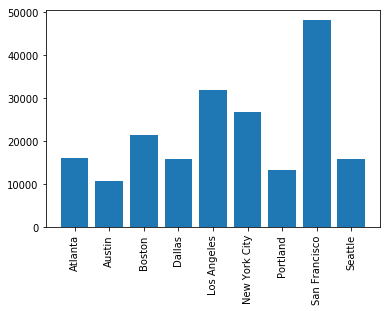

In [85]:
#Group data by cities
groupby_city = df.groupby("City")
gross_sales_by_city = groupby_city.sum()["Sale"]
gross_sales_by_city

plt.bar(gross_sales_by_city.index, gross_sales_by_city)
plt.xticks(rotation=90)
plt.show()

In [89]:
#Which city makes the best sales across all 12 months

groupby_data = df.groupby(["Month","City"]).sum()["Sale"]
groupby_data

Month    City         
2018-01  Atlanta           811
         Austin            543
         Boston           1098
         Dallas            822
         Los Angeles      1649
         New York City    1440
         Portland          719
         San Francisco    2509
         Seattle           817
2018-02  Atlanta          1056
         Austin            690
         Boston           1412
         Dallas           1013
         Los Angeles      2050
         New York City    1749
         Portland          868
         San Francisco    3045
         Seattle          1003
2018-03  Atlanta          1350
         Austin            895
         Boston           1781
         Dallas           1296
         Los Angeles      2489
         New York City    2180
         Portland         1109
         San Francisco    3910
         Seattle          1307
2018-04  Atlanta          1566
         Austin           1070
         Boston           2127
                          ... 
2018-10  Portlan

In [86]:
#display information of gross sales in every city for 1st 3 months
#loc, accedd a group of rows based on positional index
# group_data.loc[3,:] means select a specific row based on 3 and all its columns
#why use []? In pandas, using [] to access elements form df, () for function calls
groupby_data.loc[1:3, :]

NameError: name 'groupby_data' is not defined

In [87]:
# Can query individual cities (Example: Atlanta)
groupby_data.loc[1:3, "Boston"]

NameError: name 'groupby_data' is not defined

In [ ]:
#query each month sales for specific city


# create a line chart to show how the sale change in each city for 12 months?

In [88]:
# Get a list of cities
 #so there will be no duplicate
cities = df["City"].unique()
cities

array(['Boston', 'New York City', 'Portland', 'Atlanta', 'San Francisco',
       'Dallas', 'Austin', 'Los Angeles', 'Seattle'], dtype=object)

In [95]:

  #Get the city's 12 months of sales


  #Plot line plot for this city
  #parameter: only y is required

fig,ax = plt.subplots(figsize = (15,8))

for city in cities:
  current_sales = groupby_data.loc[:,city]
  ax.plot(current_sales, label=city)

plt.grid()
plt.legend()
plt.show()

TypeError: Axis must have `freq` set to convert to Periods

Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x000001F3F32AC268> (for post_execute):


ValueError: view limit minimum 0.0 is less than 1 and is an invalid Matplotlib date value. This often happens if you pass a non-datetime value to an axis that has datetime units

ValueError: view limit minimum 0.0 is less than 1 and is an invalid Matplotlib date value. This often happens if you pass a non-datetime value to an axis that has datetime units

<Figure size 1080x576 with 1 Axes>